In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams.update({'font.size': 23})

In [3]:
df = pd.read_csv("NOD_1_DF.csv")
df.head()

,branch,u,x,stable
0,0,-0.300000,3.896352e-19,True
1,0,-0.299547,3.896352e-19,True
2,0,-0.292476,3.896352e-19,True
3,0,-0.285405,3.896352e-19,True
4,0,-0.278334,3.896352e-19,True


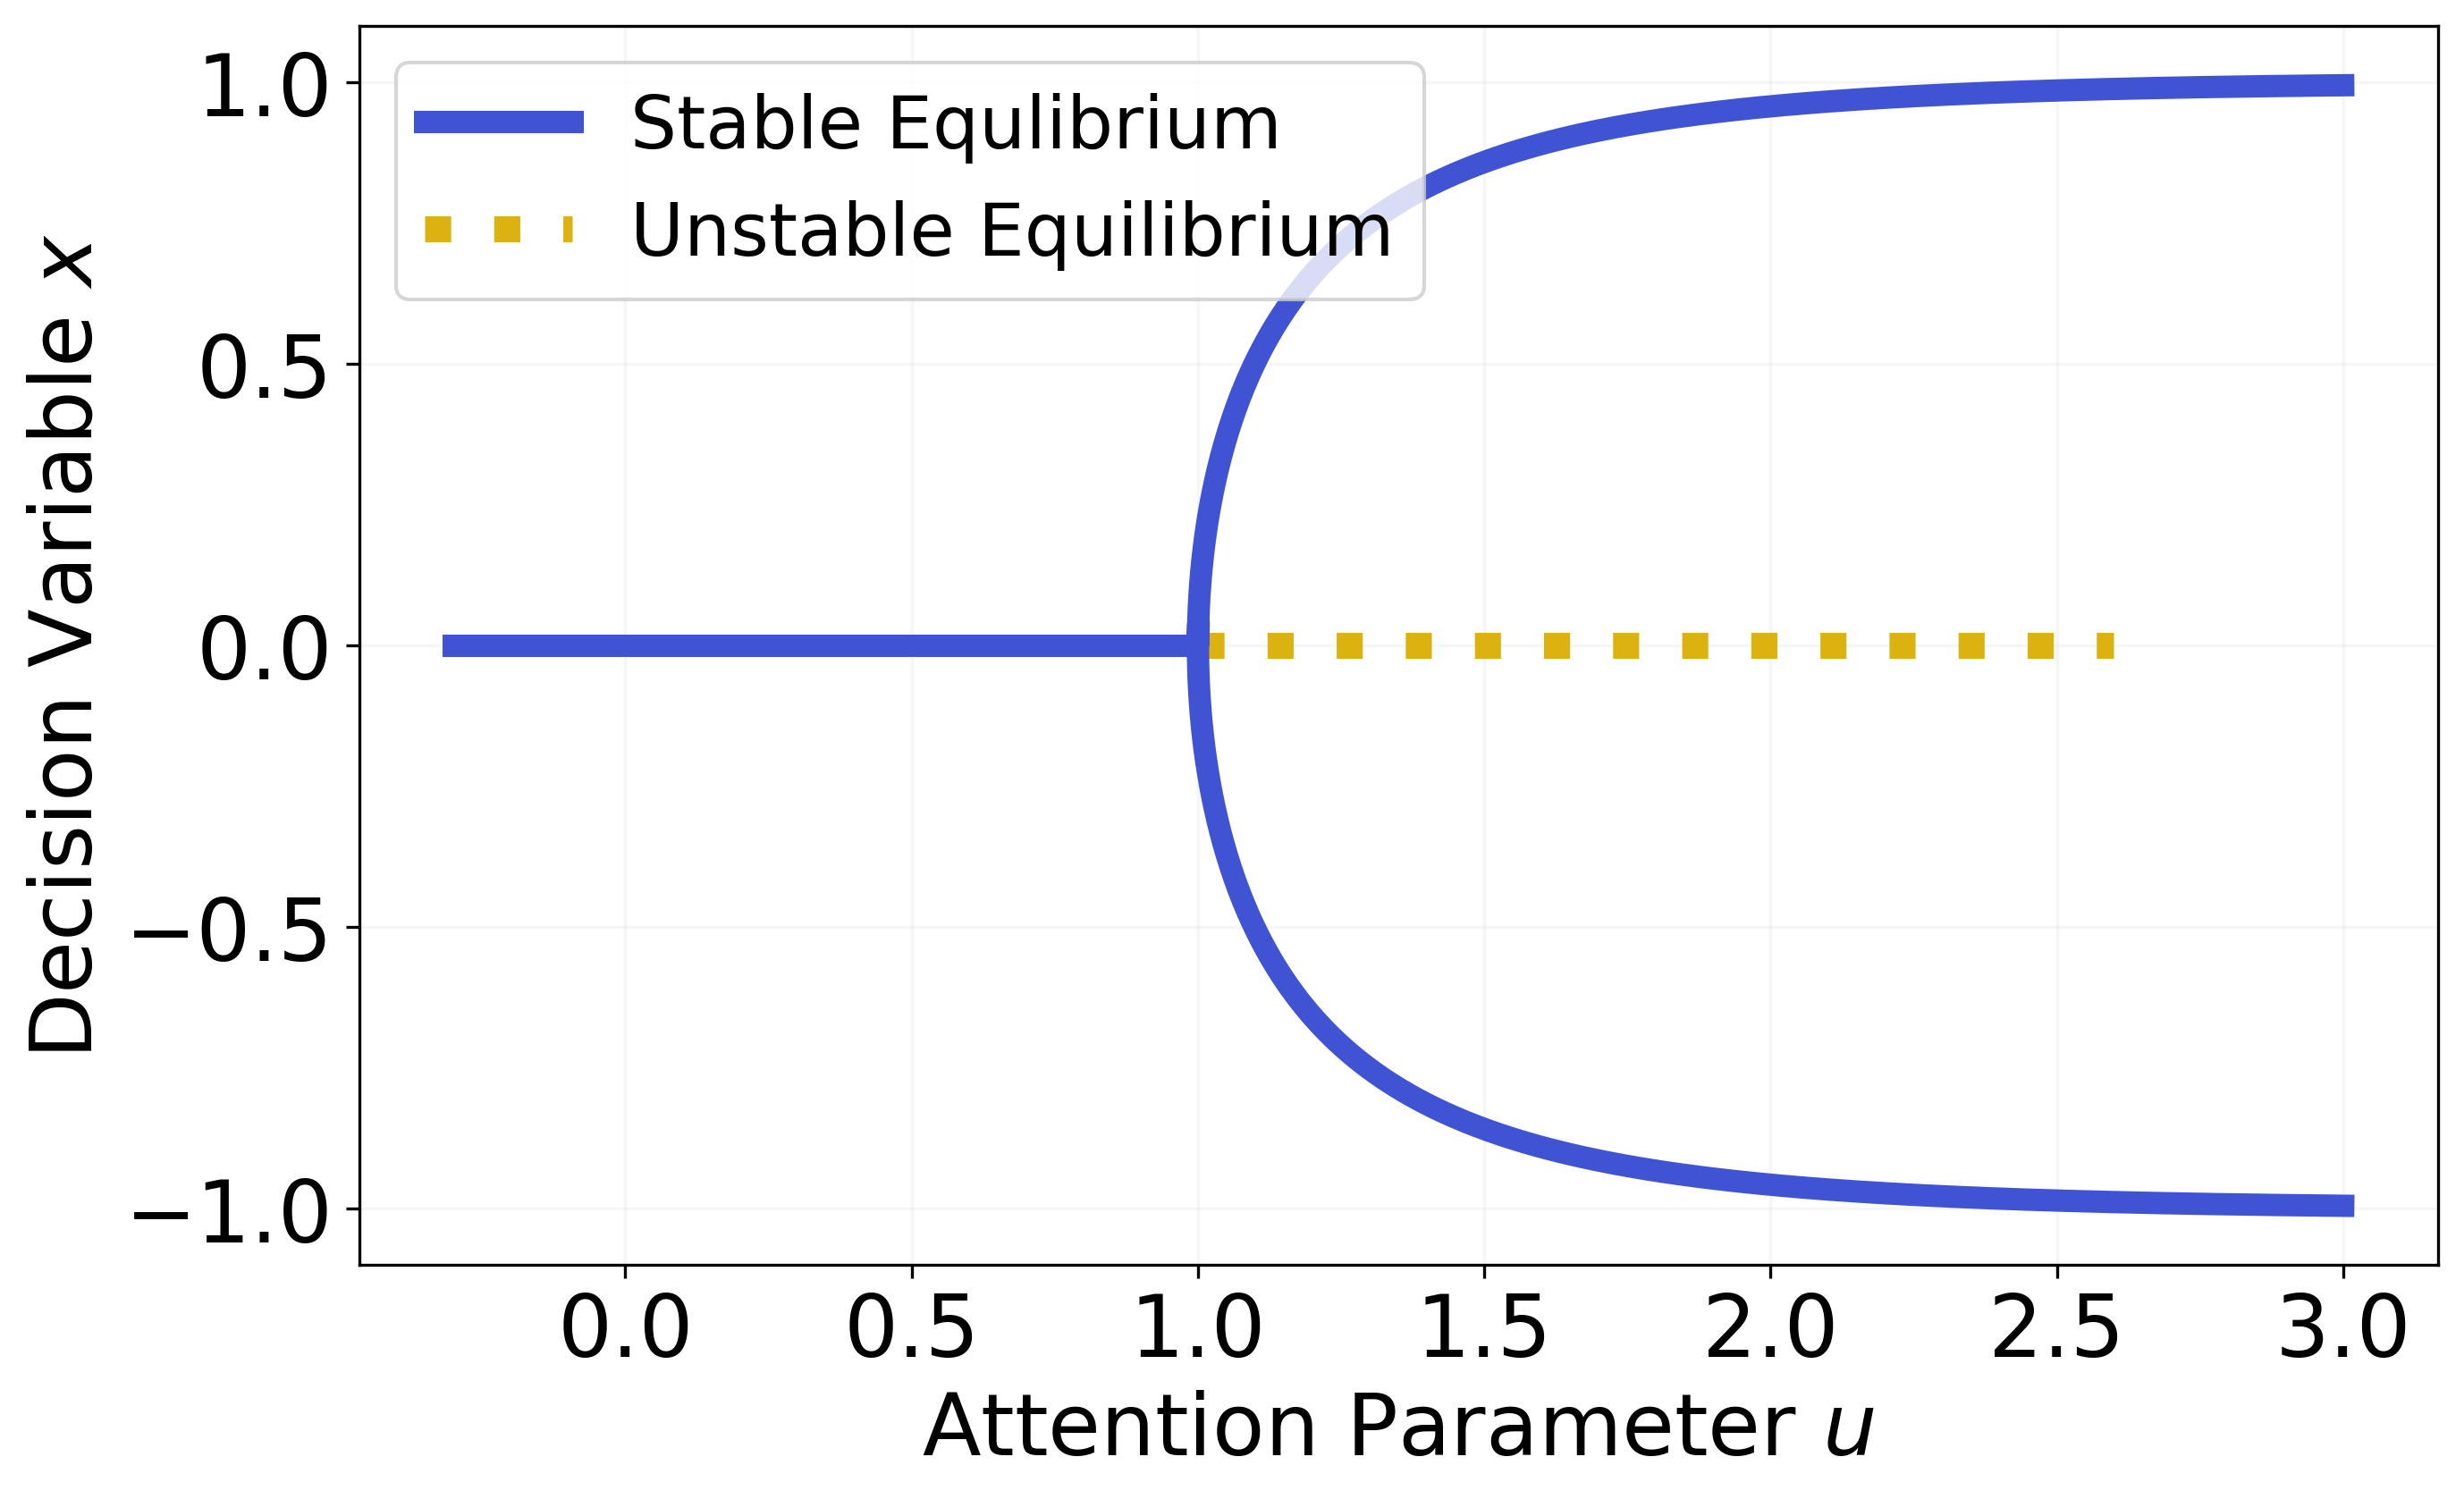

In [4]:
fig, ax = plt.subplots(figsize=(10, 6),dpi = 300)
xgfs_normal6 = np.asarray([(64, 83, 211), (221, 179, 16), (181, 29, 20), (0, 190, 255), (251, 73, 176), (0, 178, 93), (202, 202, 202)])/256
i = 0
skip = [2]
for branch, d in df.groupby("branch"):
    if branch in skip:
        continue
    ax.plot(d.loc[d.stable, "u"], d.loc[d.stable, "x"], "-",lw = 6,c = xgfs_normal6[0], label = "Stable Equlibrium" if i == 0 else None)
    i+=1
    ax.plot(d.loc[~d.stable, "u"], d.loc[~d.stable, "x"], ":",lw = 7,c = xgfs_normal6[1],label = "Unstable Equilibrium" if i == 1 else None)
    i += 1

ax.set_xlabel(r"Attention Parameter $u$")
ax.set_ylabel("Decision Variable $x$")
ax.grid(alpha = 0.1)
ax.legend(loc = "upper left",fontsize = 19.7)
ax.set_ylim(-1.1,1.1)

plt.show()


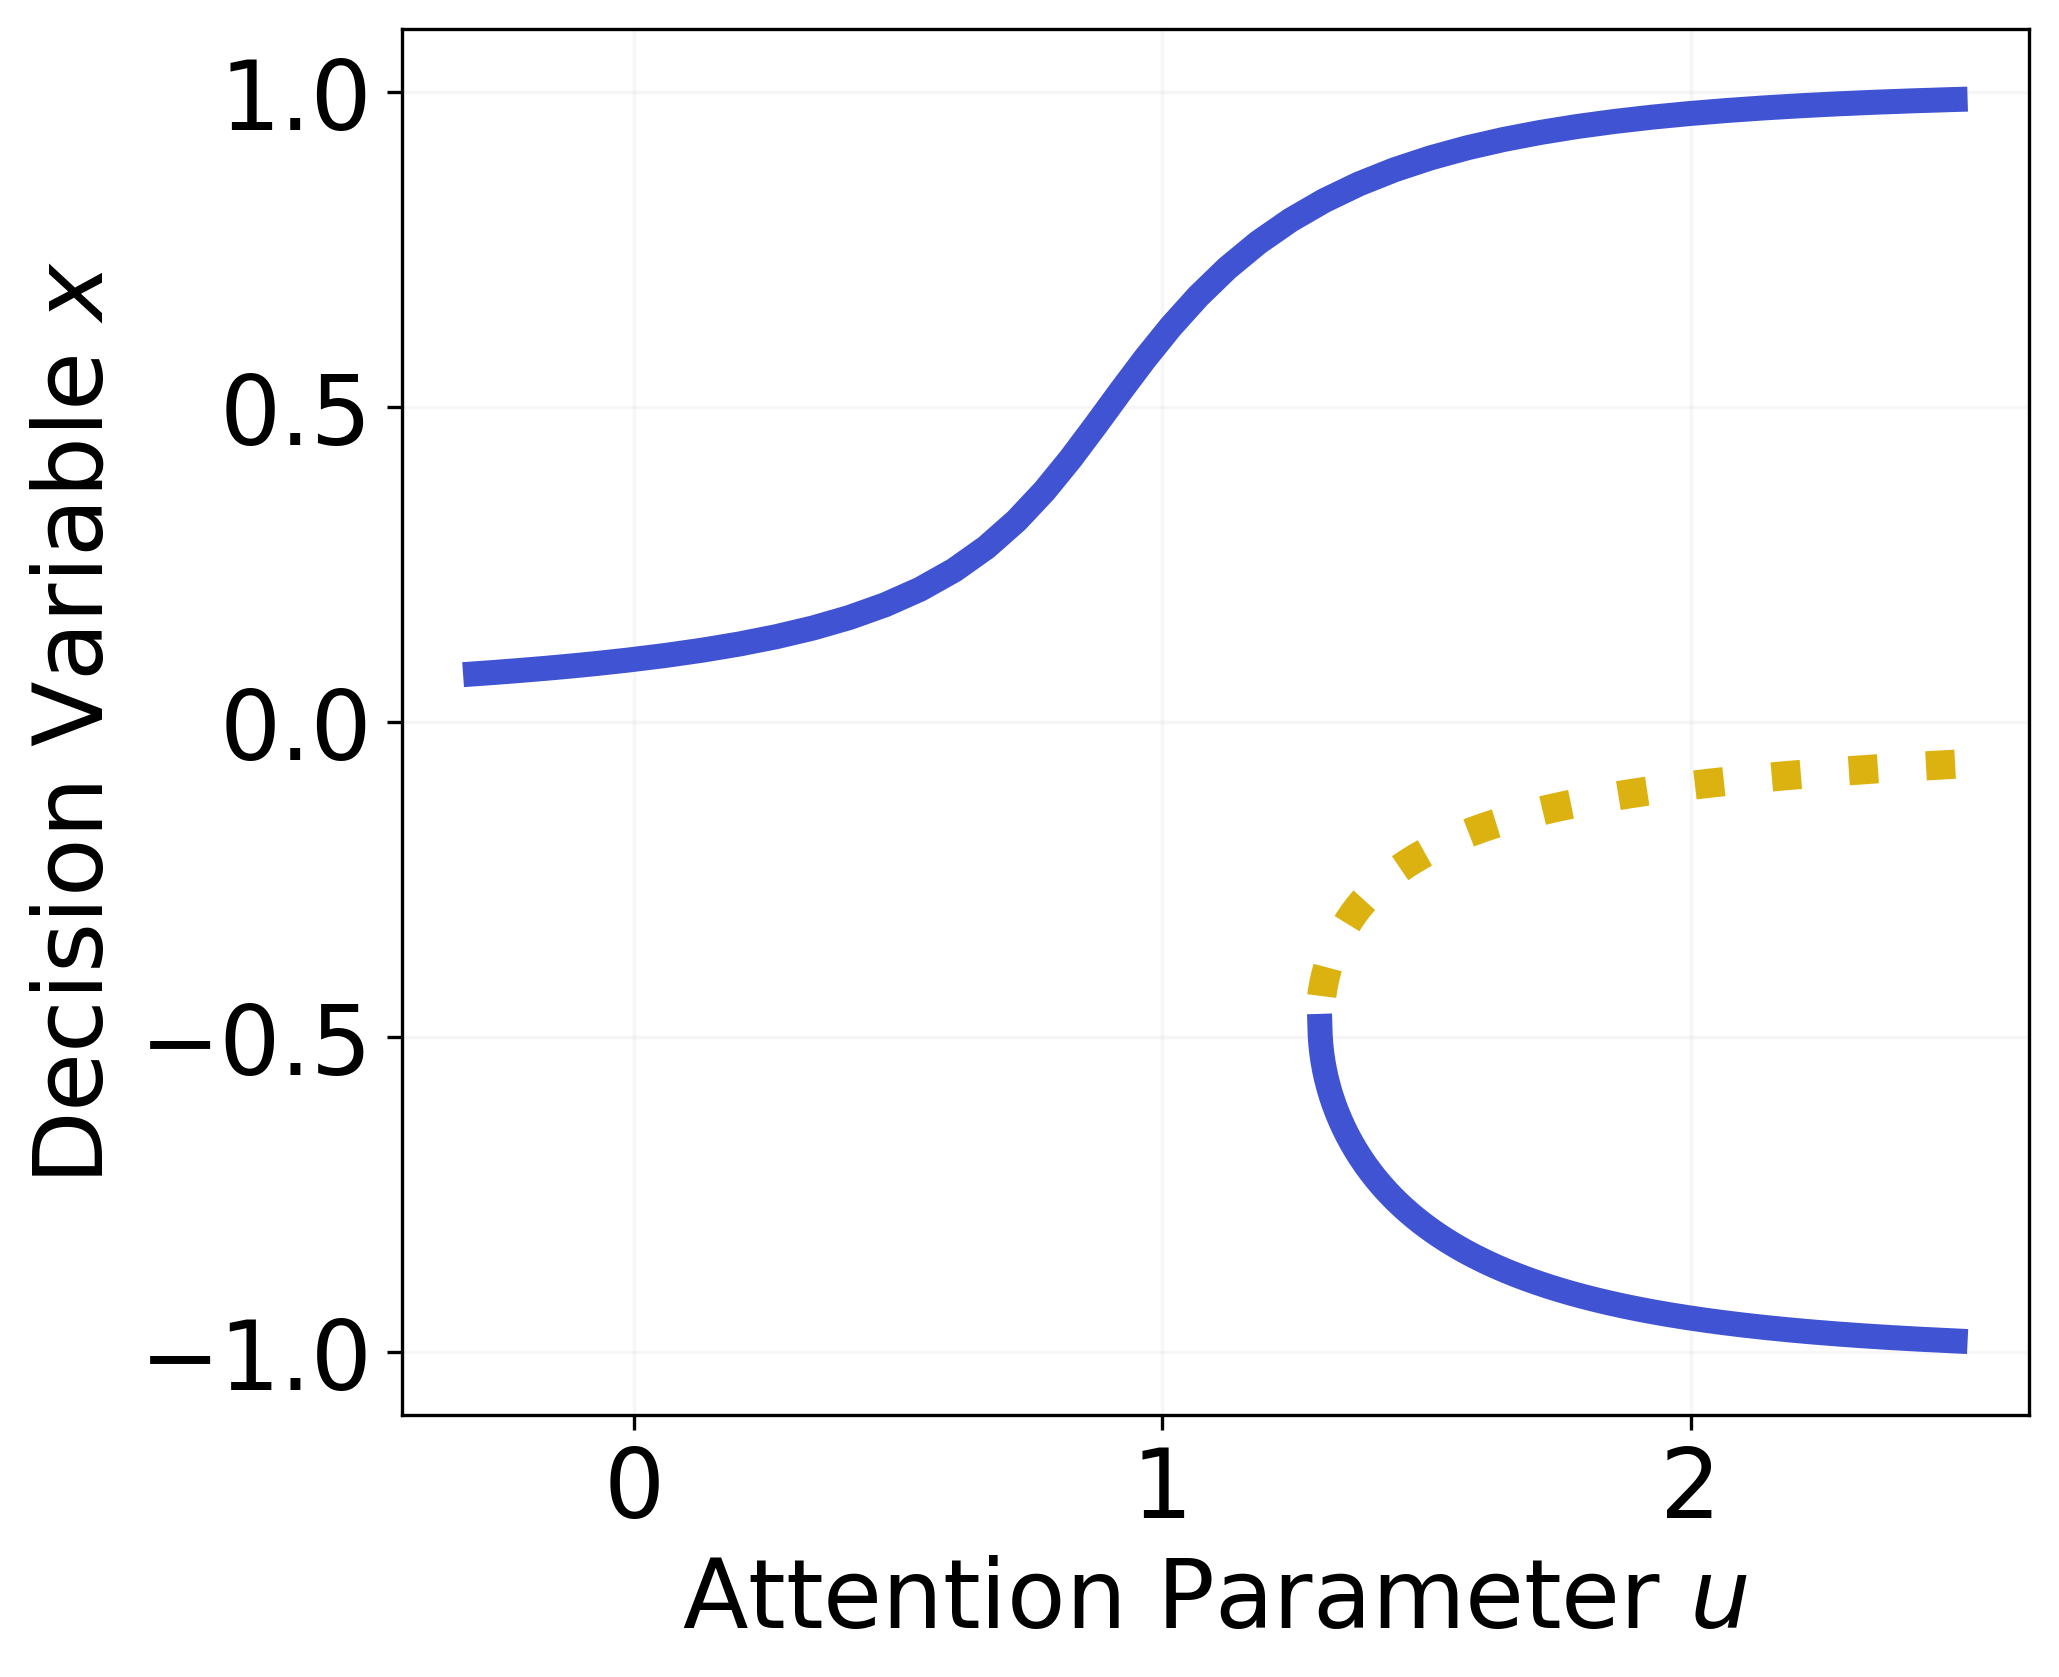

In [5]:
df2 = pd.read_csv("NOD_2_DF.csv")
df3 = pd.read_csv("NOD_3_DF.csv")

def plot_bifurcation(ax, df, stable_color, unstable_color, skip=[],legend = True,var = "x"):
    first = True

    for branch, d in df.groupby("branch"):
        if branch in skip:
            continue

        ax.plot(d.loc[d.stable, "u"],d.loc[d.stable, var],"-",lw=6,c=stable_color,label="Stable Equilibrium" if first and legend else None)

        ax.plot(d.loc[~d.stable, "u"],d.loc[~d.stable, var],":",lw=7,c=unstable_color,label="Unstable Equilibrium" if first and legend else None)

        first = False

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

plot_bifurcation(ax, df2,xgfs_normal6[0],xgfs_normal6[1],skip=[])

plot_bifurcation(ax, df3,xgfs_normal6[0],xgfs_normal6[1],skip=[],legend = False)


ax.set_xlabel(r"Attention Parameter $u$")
ax.set_ylabel("Decision Variable $x$")
ax.grid(alpha=0.1)
ax.set_ylim(-1.1,1.1)
#ax.legend(loc="lower left", fontsize=19.7)

plt.show()


In [6]:
df4 = pd.read_csv("transit_nod_blitz1.csv")
df5 = pd.read_csv("transit_nod_blitz2.csv")
df5

,branch,u,C,B,T,stable
0,0,0.500000,0.065432,0.065934,0.023313,True
1,0,0.502432,0.065415,0.065927,0.023322,True
2,0,0.509481,0.065363,0.065907,0.023350,True
3,0,0.516528,0.065309,0.065887,0.023378,True
4,0,0.523574,0.065253,0.065867,0.023407,True
...,...,...,...,...,...,...
175,0,1.273079,0.006892,0.098984,0.033048,True
176,0,1.279918,0.006744,0.099066,0.033073,True
177,0,1.286767,0.006599,0.099146,0.033097,True
178,0,1.293626,0.006458,0.099224,0.033121,True


In [7]:
plt.rcParams.update({'font.size': 20})

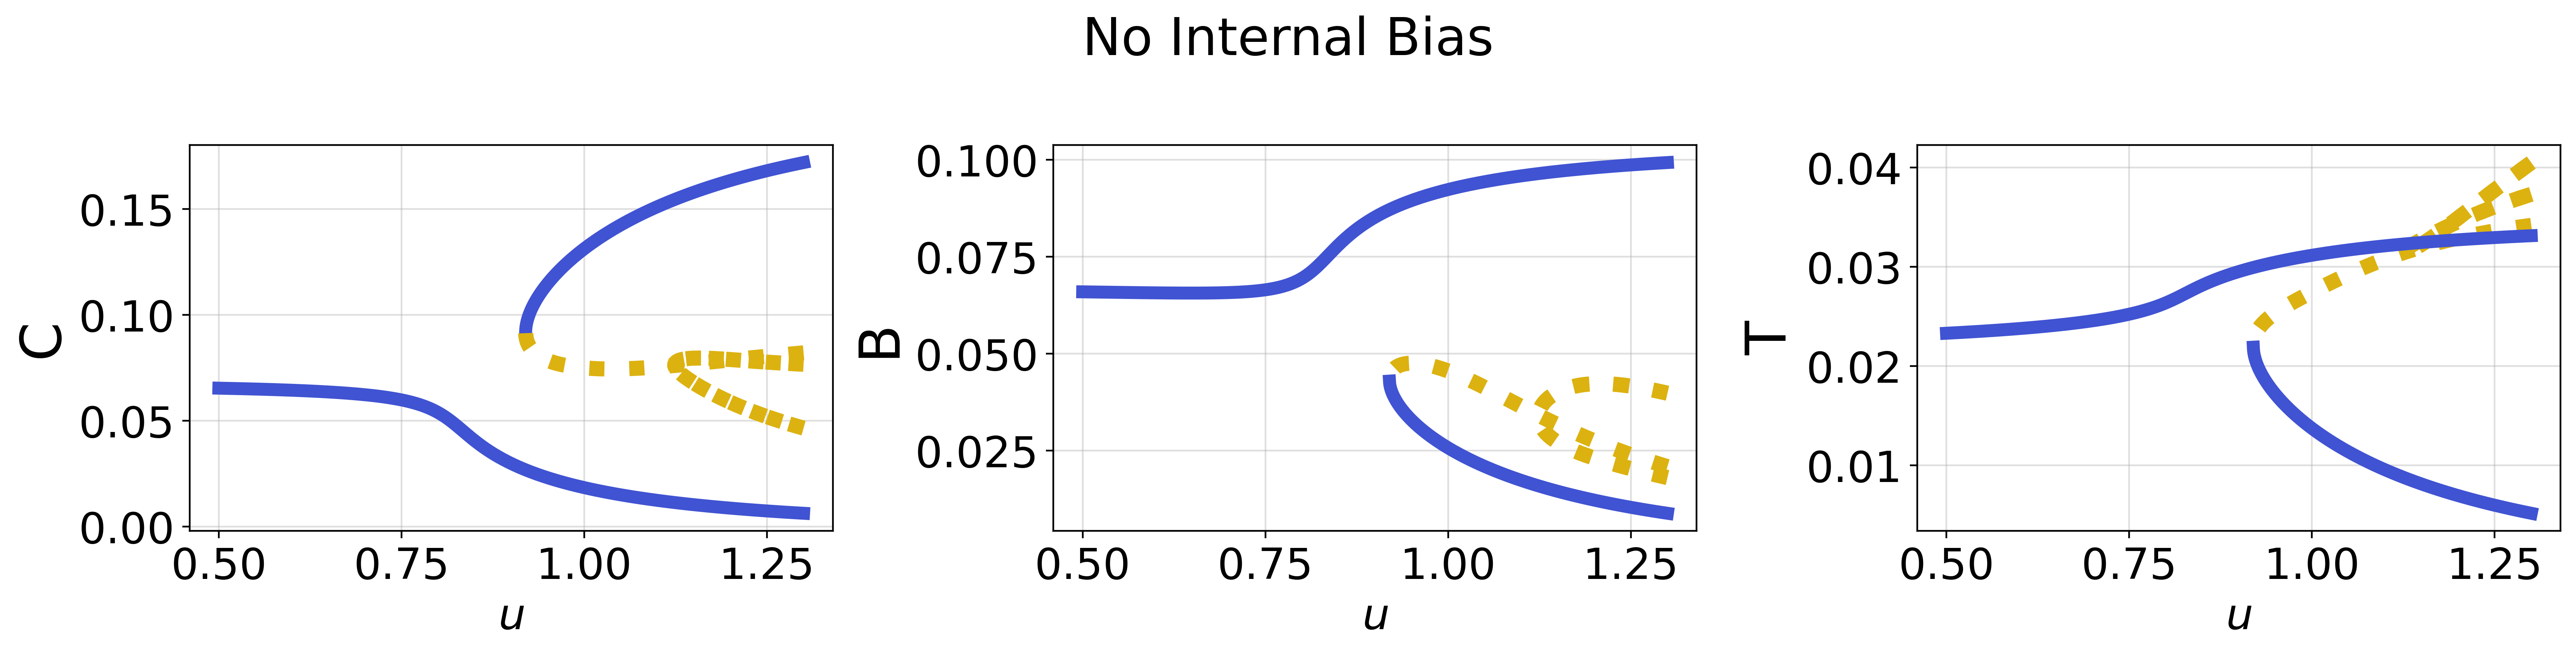

In [13]:
fig, ax = plt.subplots(1,3,figsize=(17, 4.4), dpi=400)

plot_bifurcation(ax[0], df4,xgfs_normal6[0],xgfs_normal6[1],skip=[],var ="C")
plot_bifurcation(ax[0], df5,xgfs_normal6[0],xgfs_normal6[1],skip=[],var ="C")

plot_bifurcation(ax[1], df4,xgfs_normal6[0],xgfs_normal6[1],skip=[],var ="B")
plot_bifurcation(ax[1], df5,xgfs_normal6[0],xgfs_normal6[1],skip=[],var ="B")

plot_bifurcation(ax[2], df4,xgfs_normal6[0],xgfs_normal6[1],skip=[],var ="T")
plot_bifurcation(ax[2], df5,xgfs_normal6[0],xgfs_normal6[1],skip=[],var ="T")

ax[0].set_ylabel("C",fontsize = 26)
ax[1].set_ylabel("B",fontsize = 26)
ax[2].set_ylabel("T",fontsize = 26)
plt.suptitle("No Internal Bias")

for i in range(0,3):
    ax[i].set_xlabel(r"$u$")
    ax[i].grid(alpha = 0.4)

plt.tight_layout()


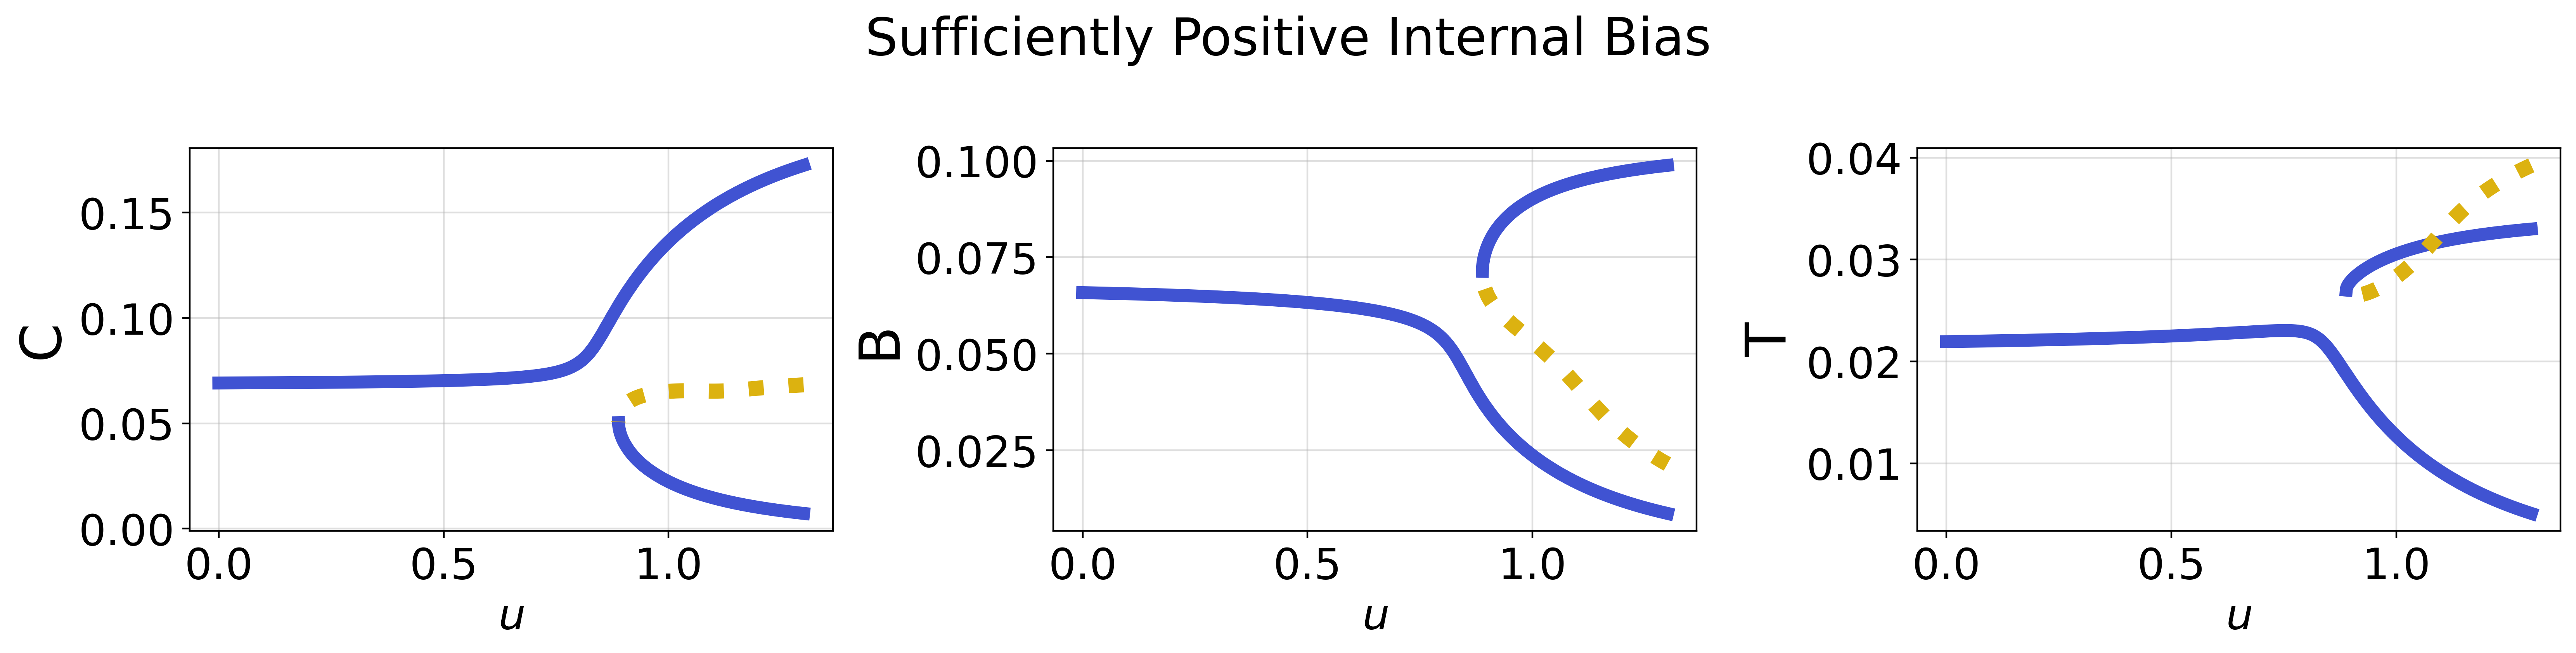

In [15]:
df6 = pd.read_csv("transit_nod_blitz1_bias.csv")
df7 = pd.read_csv("transit_nod_blitz2_bias.csv")

fig, ax = plt.subplots(1,3,figsize=(17, 4.4), dpi=400)

plot_bifurcation(ax[0], df6,xgfs_normal6[0],xgfs_normal6[1],skip=[],var ="C")
plot_bifurcation(ax[0], df7,xgfs_normal6[0],xgfs_normal6[1],skip=[],var ="C")

plot_bifurcation(ax[1], df6,xgfs_normal6[0],xgfs_normal6[1],skip=[],var ="B")
plot_bifurcation(ax[1], df7,xgfs_normal6[0],xgfs_normal6[1],skip=[],var ="B")

plot_bifurcation(ax[2], df6,xgfs_normal6[0],xgfs_normal6[1],skip=[],var ="T")
plot_bifurcation(ax[2], df7,xgfs_normal6[0],xgfs_normal6[1],skip=[],var ="T")

ax[0].set_ylabel("C",fontsize = 26)
ax[1].set_ylabel("B",fontsize = 26)
ax[2].set_ylabel("T",fontsize = 26)
plt.suptitle("Sufficiently Positive Internal Bias")

for i in range(0,3):
    ax[i].set_xlabel(r"$u$")
    ax[i].grid(alpha = 0.4)

plt.tight_layout()